# Análisis Exploratorio de Datos (EDA) y Diagnóstico de Corpus

El punto de partida de cualquier proyecto de clasificación de texto con Deep Learning
no es la arquitectura, sino el corpus. Antes de definir un solo hiperparámetro es
indispensable entender la naturaleza del dataset, porque las decisiones de diseño
que se toman aquí condicionan todo el pipeline posterior.

## ¿Qué se hace en este notebook?

El dataset utilizado es el **Jarvis Calling Hiring Contest**, compuesto por currículos
(CVs) en texto plano etiquetados con la categoría profesional del candidato. El
análisis se estructura en cuatro diagnósticos:

### 1. Distribución de clases profesionales
- **Por qué importa:** Un dataset de CVs rara vez es balanceado. Roles como
  *Software Developer* o *Data Scientist* tienden a estar sobrerepresentados respecto
  a perfiles más especializados. Si este desbalance no se detecta y se compensa
  (mediante pesos de clase o estratificación), el modelo aprenderá a predecir las
  clases mayoritarias de forma oportunista, inflando el *accuracy* global pero
  fallando sistemáticamente en las clases minoritarias.
- **Qué se genera:** un barplot horizontal que permite leer la magnitud del desbalance
  y decidir si se aplicarán pesos inversamente proporcionales a la frecuencia de clase
  en la función de pérdida.

### 2. Longitud de los textos
- **Por qué importa antes de diseñar las arquitecturas:** las redes recurrentes (BiLSTM)
  y los transformers trabajan sobre secuencias de longitud fija. Elegir un
  `sequence_length` arbitrario sin mirar los datos puede provocar dos problemas
  opuestos: truncar información semántica clave si el valor es demasiado bajo, o
  introducir padding masivo que dilata el cómputo y añade ruido a los mecanismos de
  atención si es demasiado alto.
- **Criterio utilizado:** el **percentil 95** de la distribución de longitudes. Este
  valor garantiza cobertura del 95 % del corpus sin que el 5 % de documentos más
  largos —generalmente outliers con secciones repetidas— infle innecesariamente el
  tamaño del tensor de entrada.
- **Qué se genera:** histograma con la línea del P95 y boxplot por clase, que permite
  detectar si ciertas profesiones producen CVs estructuralmente más extensos.

### 3. Frecuencia de palabras y nube de términos
- Identifica el **vocabulario dominante del corpus** una vez eliminadas las stopwords,
  revelando si el texto está dominado por términos técnicos discriminativos (lenguajes
  de programación, herramientas) o por ruido genérico de plantillas de CV.

### 4. N-gramas (bigramas y trigramas)
- Los n-gramas capturan **colocaciones multipalabra** que son invisibles en el análisis
  unigrama. Expresiones como *machine learning*, *project management* o
  *computer science* son semánticamente indivisibles y su aparición como n-gramas
  frecuentes valida que el corpus contiene señal discriminativa real.

> **Artefactos exportados:** `artifacts/raw_df.parquet` y `artifacts/eda_config.json`
> con el `sequence_length` recomendado, que el Notebook 2 leerá directamente.

In [1]:
import warnings
import logging
import re
from pathlib import Path
from collections import Counter
from itertools import chain

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

for _res, _kind in [("stopwords", "corpora"), ("punkt", "tokenizers"), ("punkt_tab", "tokenizers")]:
    try:
        nltk.data.find(f"{_kind}/{_res}")
    except LookupError:
        nltk.download(_res, quiet=True)

for d in ("figures", "artifacts"):
    Path(d).mkdir(exist_ok=True)

TEXT_COL  = "text"    # ajustar si el CSV usa otro nombre
LABEL_COL = "label"   # ajustar si el CSV usa otro nombre

print("INFO | Entorno listo.")

INFO | Entorno listo.


## 1.1 Carga de datos

In [4]:
import os
import pandas as pd
from pathlib import Path

# Usamos .resolve() para asegurar que la ruta sea absoluta y evitar problemas en Windows
DATA_DIR = Path("../data/data").resolve() 

def load_resumes_from_folders(base_dir: Path) -> pd.DataFrame:
    data_list = []
    
    if not base_dir.exists():
        raise FileNotFoundError(f"No se encontró la carpeta de datos en: {base_dir}")
    
    # Recorremos cada subcarpeta (cada profesión es una clase)
    for category_folder in base_dir.iterdir():
        if category_folder.is_dir():
            label = category_folder.name  # El nombre de la carpeta (ej: ACCOUNTANT)
            
            # Recorremos los archivos dentro de la subcarpeta
            for file_path in category_folder.glob("*"):
                if file_path.is_file():
                    text = ""  # Inicializamos vacío para evitar errores de referencia
                    try:
                        # Si son archivos de texto plano (.txt)
                        if file_path.suffix.lower() == '.txt':
                            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                                text = f.read()
                        
                        # Si son PDFs
                        elif file_path.suffix.lower() == '.pdf':
                            from pypdf import PdfReader
                            reader = PdfReader(file_path)
                            text = "".join([page.extract_text() for page in reader.pages if page.extract_text()])
                        
                        # Guardamos solo si logramos extraer texto real
                        if text and text.strip():
                            data_list.append({"text": text.strip(), "label": label})
                            
                    except Exception as e:
                        print(f"Error leyendo {file_path.name}: {e}")
                        
    return pd.DataFrame(data_list)

# Ejecución
df = load_resumes_from_folders(DATA_DIR)
print(f"Shape consolidado: {df.shape}")
print("\nDistribución de clases:\n", df["label"].value_counts())

Shape consolidado: (2483, 2)

Distribución de clases:
 label
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
ACCOUNTANT                118
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
FINANCE                   118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
CONSULTANT                115
HEALTHCARE                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [5]:
# Estadísticas básicas de la columna de texto
print(df[TEXT_COL].describe())
print()
print("Distribución de clases:")
print(df[LABEL_COL].value_counts())

count                                                  2483
unique                                                 2481
top       STOREKEEPER II\nProfessional Summary\nThe purp...
freq                                                      2
Name: text, dtype: object

Distribución de clases:
label
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
ACCOUNTANT                118
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
FINANCE                   118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
CONSULTANT                115
HEALTHCARE                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO          

## 1.2 Distribución de clases

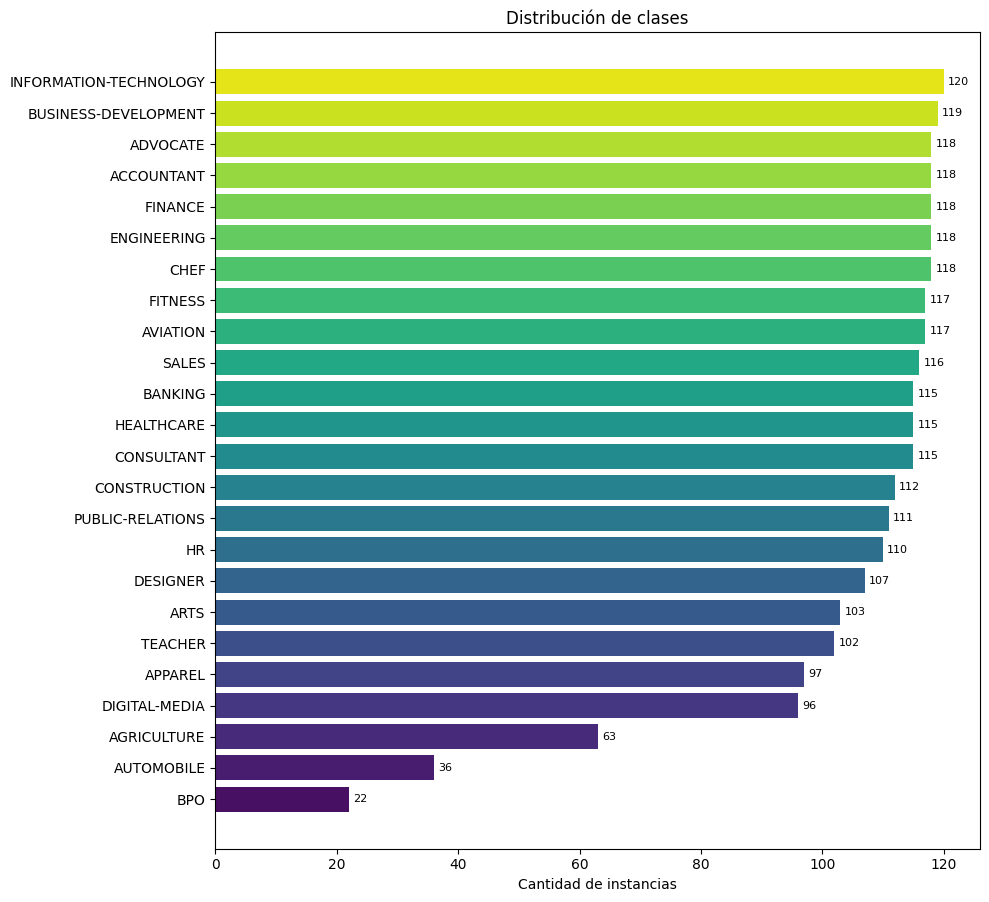

INFO | Gráfico de clases guardado.


In [7]:
def plot_class_distribution(df: pd.DataFrame) -> None:
    """
    Barplot horizontal: evita solapamiento en datasets con nombres de intento largos.
    """
    counts = df[LABEL_COL].value_counts().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(counts) * 0.38)))

    palette = sns.color_palette("viridis", len(counts))
    bars = ax.barh(counts.index, counts.values, color=palette)
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_xlabel("Cantidad de instancias")
    ax.set_title("Distribución de clases")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )
    plt.tight_layout()
    fig.savefig("figures/class_distribution.png", dpi=150)
    plt.show()
    logger.info("Gráfico de clases guardado.")

plot_class_distribution(df)

## 1.3 Longitud de textos — histograma y boxplot

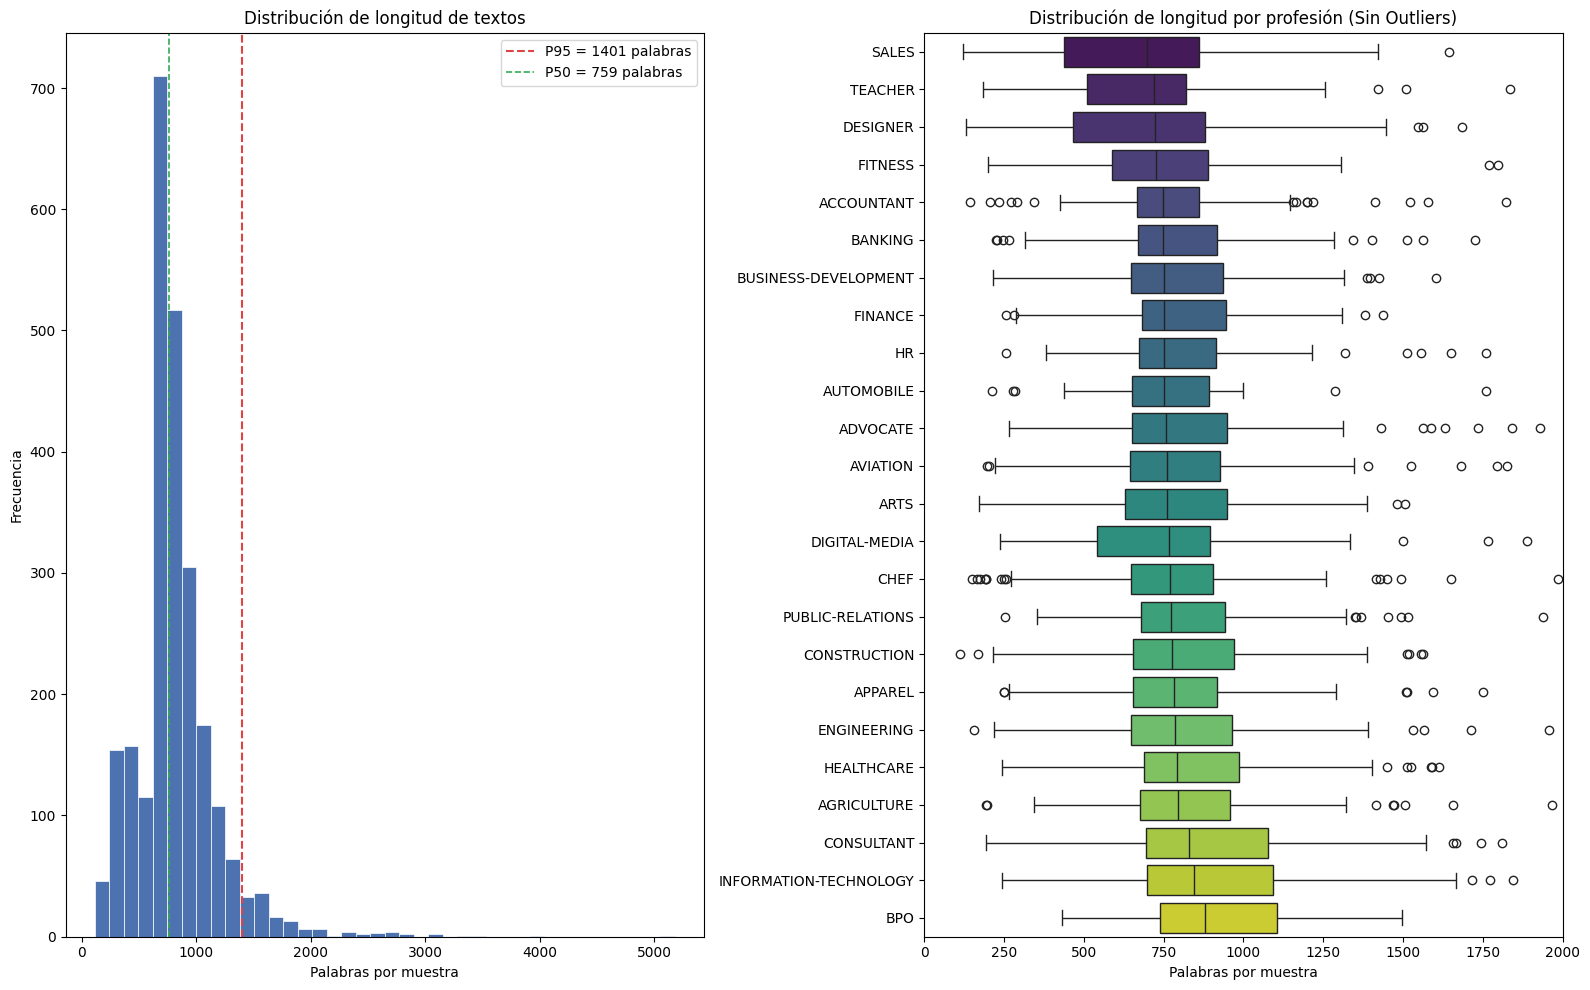

INFO | Análisis de longitud completo. sequence_length recomendado (P95): 1401.



INFO | sequence_length recomendado → 1401


In [12]:
def plot_text_length_analysis(df: pd.DataFrame) -> int:
    lengths = df[TEXT_COL].apply(lambda t: len(t.split()))
    p50 = int(np.percentile(lengths, 50))
    p95 = int(np.percentile(lengths, 95))

    # Creamos UN SOLO lienzo con 1 fila y 2 columnas, ampliando el tamaño vertical (10)
    fig, axes = plt.subplots(1, 2, figsize=(16, 10))

    # --- GRÁFICO 1: Histograma (Izquierda) ---
    axes[0].hist(lengths, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.5)
    axes[0].axvline(p95, color="#DD4444", linestyle="--", linewidth=1.5,
                    label=f"P95 = {p95} palabras")
    axes[0].axvline(p50, color="#33AA55", linestyle="--", linewidth=1.2,
                    label=f"P50 = {p50} palabras")
    axes[0].set_xlabel("Palabras por muestra")
    axes[0].set_ylabel("Frecuencia")
    axes[0].set_title("Distribución de longitud de textos")
    axes[0].legend()

    # --- GRÁFICO 2: Boxplot por clase (Derecha) ---
    length_df = pd.DataFrame({"length": lengths, "label": df[LABEL_COL]})
    order = length_df.groupby("label")["length"].median().sort_values().index
    
    # Dibujamos sobre el segundo eje (axes[1])
    # Usamos showfliers=False para ocultar los outliers masivos que deforman el eje X
    sns.boxplot(
        data=length_df, 
        x="length", 
        y="label", 
        order=order,
        ax=axes[1], 
        palette="viridis", 
    )
    
    # Acotamos el eje X entre 0 y 2000 palabras para que las cajas respiren
    axes[1].set_xlim(0, 2000)
    axes[1].set_xlabel("Palabras por muestra")
    axes[1].set_ylabel("")
    axes[1].set_title("Distribución de longitud por profesión (Sin Outliers)", fontsize=12)

    # Ajuste final de los subplots para evitar solapamientos
    plt.tight_layout()
    
    # Guardamos y mostramos la figura unificada
    fig.savefig("figures/text_length_analysis.png", dpi=150)
    plt.show()
    
    logger.info(
        "Análisis de longitud completo. sequence_length recomendado (P95): %d.", p95
    )
    return p95

# Ejecución
RECOMMENDED_SEQ_LEN = plot_text_length_analysis(df)
print(f"\nINFO | sequence_length recomendado → {RECOMMENDED_SEQ_LEN}")

## 1.4 Frecuencia de palabras — Top 20 y WordCloud

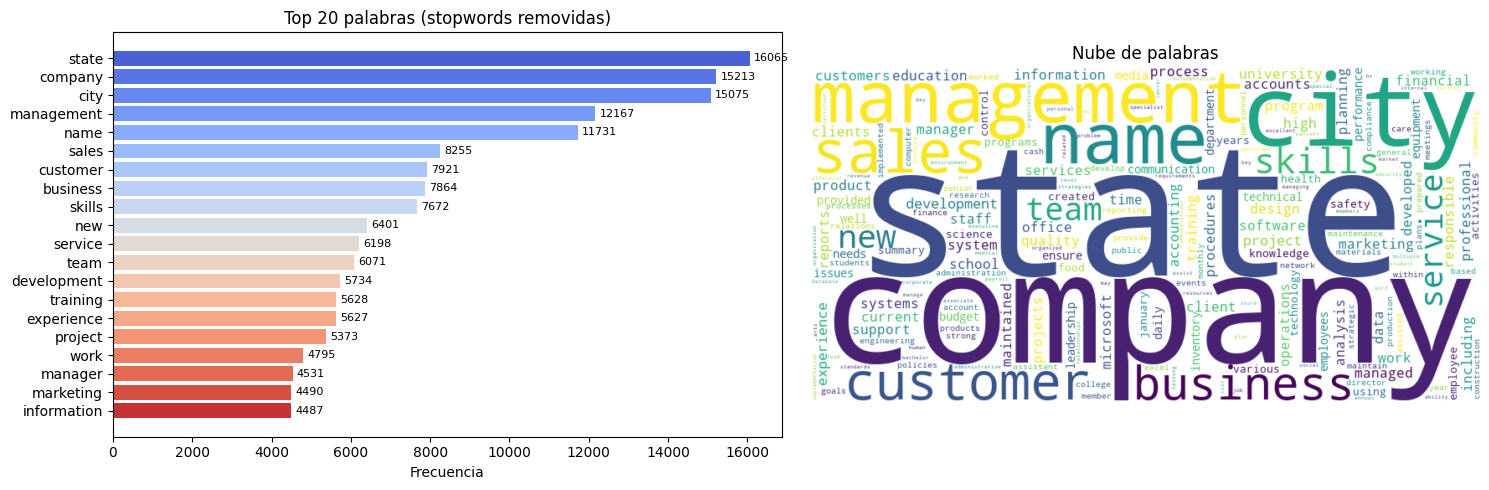

INFO | Análisis de frecuencia guardado.


In [13]:
_NOISE = re.compile(r"[^a-zA-Z\s]")
_STOP  = set(stopwords.words("english"))

def _clean_for_freq(text: str) -> list:
    text = _NOISE.sub(" ", text.lower())
    return [w for w in text.split() if w and w not in _STOP and len(w) > 1]

def plot_word_frequency(df: pd.DataFrame, top_n: int = 20) -> None:
    all_tokens = list(chain.from_iterable(
        _clean_for_freq(t) for t in df[TEXT_COL]
    ))
    freq = Counter(all_tokens)
    top_words, top_counts = zip(*freq.most_common(top_n))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Barplot Top-N
    palette = sns.color_palette("coolwarm", top_n)
    axes[0].barh(
        list(reversed(top_words)),
        list(reversed(top_counts)),
        color=list(reversed(palette))
    )
    axes[0].set_xlabel("Frecuencia")
    axes[0].set_title(f"Top {top_n} palabras (stopwords removidas)")
    axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=8)

    # WordCloud con peso de frecuencia real
    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap="viridis",
        max_words=200,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(freq)
    axes[1].imshow(wc, interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title("Nube de palabras")

    plt.tight_layout()
    fig.savefig("figures/word_frequency.png", dpi=150)
    plt.show()
    logger.info("Análisis de frecuencia guardado.")

plot_word_frequency(df)

## 1.5 N-gramas — bigramas y trigramas

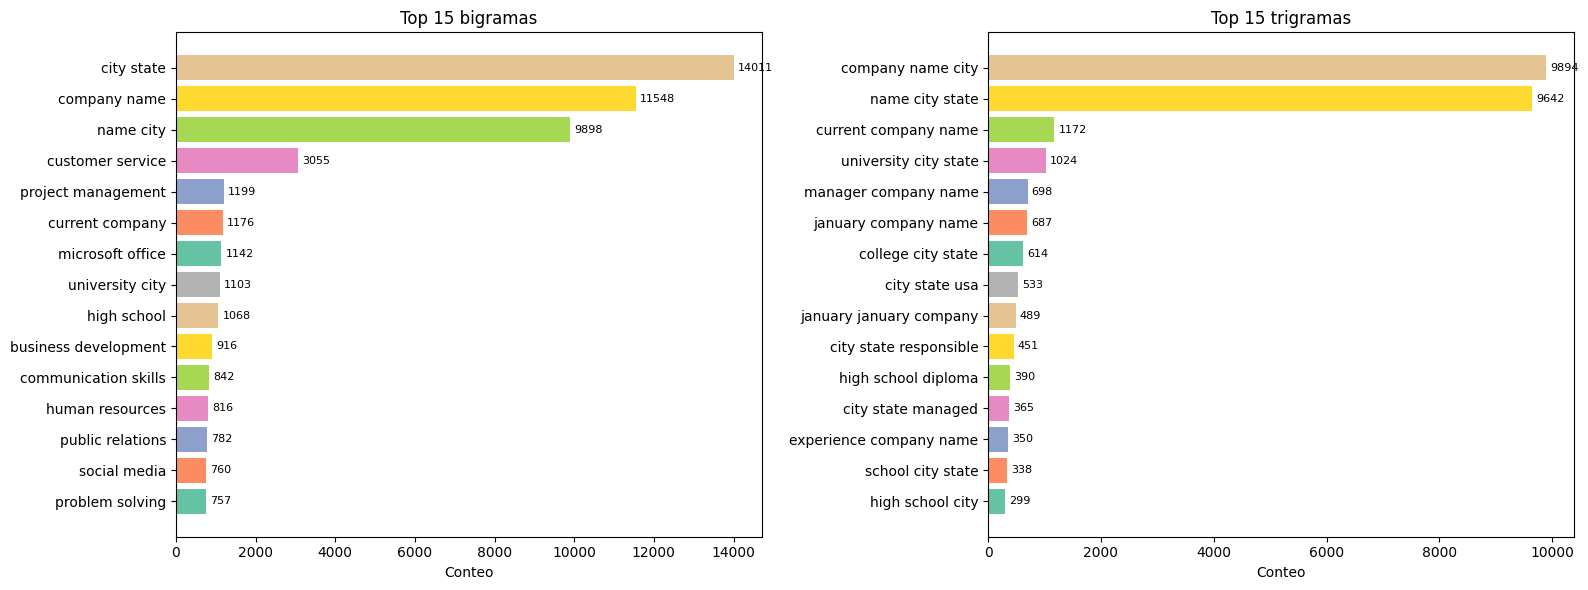

INFO | N-gramas guardados.


In [14]:
def plot_ngrams(df: pd.DataFrame, top_n: int = 15) -> None:
    """
    Los n-gramas revelan intenciones compuestas invisibles en análisis unigrama
    (ej. 'play music', 'set alarm').
    """
    token_lists = [_clean_for_freq(t) for t in df[TEXT_COL]]
    bigram_counts  = Counter(chain.from_iterable(ngrams(tl, 2) for tl in token_lists))
    trigram_counts = Counter(chain.from_iterable(ngrams(tl, 3) for tl in token_lists))

    def _draw(ax, counter, label):
        items, values = zip(*counter.most_common(top_n))
        labels = [" ".join(g) for g in reversed(items)]
        values = list(reversed(values))
        ax.barh(labels, values, color=sns.color_palette("Set2", top_n))
        ax.set_xlabel("Conteo")
        ax.set_title(f"Top {top_n} {label}")
        ax.bar_label(ax.containers[0], padding=3, fontsize=8)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    _draw(axes[0], bigram_counts,  "bigramas")
    _draw(axes[1], trigram_counts, "trigramas")
    plt.tight_layout()
    fig.savefig("figures/ngrams.png", dpi=150)
    plt.show()
    logger.info("N-gramas guardados.")

plot_ngrams(df)

## 1.6 Exportar artefactos para el Notebook 2

In [15]:
df.to_parquet("artifacts/raw_df.parquet", index=False)

import json
with open("artifacts/eda_config.json", "w") as f:
    json.dump({"recommended_seq_len": RECOMMENDED_SEQ_LEN}, f)

logger.info("Artefactos exportados: artifacts/raw_df.parquet, artifacts/eda_config.json")

INFO | Artefactos exportados: artifacts/raw_df.parquet, artifacts/eda_config.json
